# 텐서플로를 사용한 사용자 정의 모델과 훈련

In [ ]:
import sys
# 코랩의 경우 나눔 폰트를 설치합니다.
if 'google.colab' in sys.modules:
    !sudo apt-get -qq -y install fonts-nanum
    import matplotlib.font_manager as fm
    font_files = fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum'])
    for fpath in font_files:
        fm.fontManager.addfont(fpath)

# 나눔 폰트를 사용합니다.
import matplotlib

matplotlib.rc('font', family='NanumBarunGothic')
matplotlib.rcParams['axes.unicode_minus'] = False

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 126284 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


## 저수준 파이썬 API를 통한 사용자 정의 모델의 필요성
- 자신만의 손실함수, 모델, 초기화 등을 만들어 세부적으로 제어하고 싶을 때 사용

# 1. 텐서플로 훓어보기

## 텐서플로가 제공하는 것
- 핵심구조는 넘파이와 유사하지만 `GPU`지원
- 분산 컴퓨팅 지원
- JIT(Just In Time) 컴파일러 포함
    - 속도는 높이지만 메모리 사용량을 줄이기 위해 계산 최적화
    - 계산 그래프를 추춸하고 최적화해 사용하지 않는 노드 가지치기
- 계산 그래프는 플랫폼 중립적인 포맷으로 보낼 수 있음 -> 다른 환경에서 실행 가능
- 텐서플로는 후진 모드 자동 미분과 고성능 옵티마이저를 제공 -> 손실함수를 쉽게 최소화 가능



- 텐서플로 파이썬 API 예시

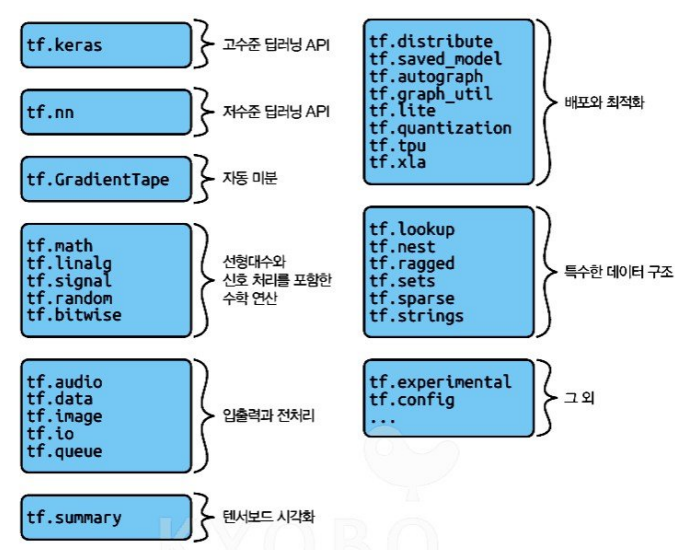

## 텐서플로의 연산
- 텐서플로의 연산(op)는 C++ 코드로 구현
- 많은 연산은 `커널`이라는 여러 구현을 가짐
  - 각 커널은 CPU,GPU, TPU(텐서 처리 장치)와 같은 특정 장치에 맞춰 만들어짐
- 대부분의 코드는 케라스 같은 `고수준 API`를 사용
- 높은 자유도가 필요한 경우 `저수준 API`를 사용하여 텐서를 직접 다룰 수 있음


## 텐서플로 생태계
- `텐서 보드` : 시각화를 위한 툴
- `TFX` : 텐서플로 제품화를 위한 라이브러리
- `텐서플로 허브` : 사전 훈련된 신경망 허브
- `텐서플로 모델 저장소` : 신경망 구조 다운로드 가능
- `텐서플로 리소스 페이지` : 텐서플로 기반 프로젝트 리스트

---

# 2. 넘파이처럼 텐서플로 사용하기

## 텐서 (Tensor)
- 텐서플로 API는 `텐서`를 순환시킴
  - 텐서는 한 연산에서 다른 연산으로 흐름
- 텐서는 `다차원 배열`
  - `np.ndarray`와 유사함
  - 차이점 : `스칼라값`도 가질 수 있음

## 텐서와 연산

### tf.constant() : 상수 텐서
- `tf.constant()`를 통해 상수 텐서 생성 가능
- 크기(shape) 과 타입(type)을 가짐

In [ ]:
import tensorflow as tf

### 행렬 선언
t = tf.constant([[1.,2.,3.],
                            [4.,5.,6.]])
print(t)
print("t 크기 : ",t.shape)
print("t 타입 : ",t.dtype)

tf.Tensor(
[[1. 2. 3.]
 [4. 5. 6.]], shape=(2, 3), dtype=float32)
t 크기 :  (2, 3)
t 타입 :  <dtype: 'float32'>


### 텐서의 인덱싱
- 넘파이와 유사하게 [행, 열,간격] 으로 진행됨

In [ ]:
### 0번째 열 제외
print("t[:, 1:] = ",t[:, 1:])

### 모든 행에서 1번 인덱스만 + 새로운 줄 추가
print("t[..., 1, tf.newaxis] = ", t[..., 1, tf.newaxis])

t[:, 1:] =  tf.Tensor(
[[2. 3.]
 [5. 6.]], shape=(2, 2), dtype=float32)
t[..., 1, tf.newaxis] =  tf.Tensor(
[[2.]
 [5.]], shape=(2, 1), dtype=float32)


### 텐서의 연산
- 대다수 넘파이에서 볼 수 있는 연산을 동일하게 제공
  - tf.add()
  - tf.multiply()
  - tf.square()
  - tf.exp()
  - tf.sqrt()
  - tf.reshape()
  - tf.squeeze()
  - tf.tile()

- 다만 일부함수는 이름이 다름
  - tf.reduce_mean()
  - tf.reduce_sum()
  - tf.reduce_max()
  - tf.math.log()
  - tf.transpose(T)

In [ ]:
### 덧셈
print(t+10)
print(tf.add(t,10))

### 제곱
print(tf.square(t))

### 행렬 곱셈 @ 전치행렬
print(t@tf.transpose(t))

tf.Tensor(
[[11. 12. 13.]
 [14. 15. 16.]], shape=(2, 3), dtype=float32)
tf.Tensor(
[[11. 12. 13.]
 [14. 15. 16.]], shape=(2, 3), dtype=float32)
tf.Tensor(
[[ 1.  4.  9.]
 [16. 25. 36.]], shape=(2, 3), dtype=float32)
tf.Tensor(
[[14. 32.]
 [32. 77.]], shape=(2, 2), dtype=float32)


### 스칼라 값 부여

In [ ]:
tf.constant(42)

<tf.Tensor: shape=(), dtype=int32, numpy=42>

## 텐서와 넘파이
- 넘파이 배열과 텐서는 상호 변환이 가능

- `tf.constant(<넘파이배열>)`을 이용해 넘파이배열을 텐서로 변환

In [ ]:
import numpy as np

a = np.array([2., 4., 5.])
tf.constant(a)

<tf.Tensor: shape=(3,), dtype=float64, numpy=array([2., 4., 5.])>

## 타입 변환
- 텐서플로는 타입 변환을 자동으로 수행하지 않음
- 타입 변환이 성능을 크게 감소 시킬 가능 성이 있음
- `tf.cast()`를 통해서 형변환이 가능

In [ ]:
try:
    tf.constant(2.0) + tf.constant(40)
except tf.errors.InvalidArgumentError as ex:
    print(ex)

t2 = tf.constant(40., dtype=tf.float64)
print(tf.constant(2.0) + tf.cast(t2, tf.float32))

cannot compute AddV2 as input #1(zero-based) was expected to be a float tensor but is a int32 tensor [Op:AddV2] name: 
tf.Tensor(42.0, shape=(), dtype=float32)


## tf.Variable : 텐서플로 변수
- 역전파 혹은 신경망의 가중치 구현을 위해 변경이 가능한 텐서 변수
- tf.Tensor와 비슷하게 작동하지만 차이점이 존재함
  - `assign()` 매서드를 이용해 변수 값을 변경 가능
  -`scatter_update()` 등을 이용해 개별 원소 수정 가능
  - 단, 직접 수정 불가

In [ ]:
v = tf.Variable([[1., 2., 3.], [4., 5., 6.]])
print("v = ", v)

### assign : 변수값 변경
v.assign(2 * v)
print("v.assign(2 * v) : ",v)

v[0, 1].assign(42)
print("v[0, 1].assign(42) : ",v)


v[:, 2].assign([0., 1.])
print("v[:, 2].assign([0., 1.]) : ",v)

### scatter : 개별 원소 값 변경
v.scatter_nd_update(
    indices=[[0, 0], [1, 2]], updates=[100., 200.])
print("v.scatter_nd_update(indices=[[0, 0], [1, 2]], updates=[100., 200.]) : ",v)

sparse_delta = tf.IndexedSlices(values=[[1., 2., 3.], [4., 5., 6.]],
                                indices=[1, 0])
v.scatter_update(sparse_delta)
print("v.scatter_update : ",v)

### 직접 수정 불가
try:
    v[1] = [7., 8., 9.]
except TypeError as ex:
    print(ex)

v =  <tf.Variable 'Variable:0' shape=(2, 3) dtype=float32, numpy=
array([[1., 2., 3.],
       [4., 5., 6.]], dtype=float32)>
v.assign(2 * v) :  <tf.Variable 'Variable:0' shape=(2, 3) dtype=float32, numpy=
array([[ 2.,  4.,  6.],
       [ 8., 10., 12.]], dtype=float32)>
v[0, 1].assign(42) :  <tf.Variable 'Variable:0' shape=(2, 3) dtype=float32, numpy=
array([[ 2., 42.,  6.],
       [ 8., 10., 12.]], dtype=float32)>
v[:, 2].assign([0., 1.]) :  <tf.Variable 'Variable:0' shape=(2, 3) dtype=float32, numpy=
array([[ 2., 42.,  0.],
       [ 8., 10.,  1.]], dtype=float32)>
v.scatter_nd_update(indices=[[0, 0], [1, 2]], updates=[100., 200.]) :  <tf.Variable 'Variable:0' shape=(2, 3) dtype=float32, numpy=
array([[100.,  42.,   0.],
       [  8.,  10., 200.]], dtype=float32)>
v.scatter_update :  <tf.Variable 'Variable:0' shape=(2, 3) dtype=float32, numpy=
array([[4., 5., 6.],
       [1., 2., 3.]], dtype=float32)>
'ResourceVariable' object does not support item assignment


### 다른 데이터 구조
- 희소 텐서 (tf.SparseTensor)
- 텐서 배열 (tf.TensorArray)
- 레그드 텐서 (tf.RaggedTensor)
- 문자열 텐서 (tf.string)
- 집합 (tf.sets)
- 큐 (tf.queue)

------

# 3. 사용자 정의 모델과 훈련 알고리즘

## 사용자 정의 손실함수
> 예시 : 후버 손실 구현

In [ ]:
def huber_fn(y_true, y_pred):
    error = y_true - y_pred
    is_small_error = tf.abs(error) < 1
    squared_loss = tf.square(error) / 2
    linear_loss  = tf.abs(error) - 0.5
    return tf.where(is_small_error, squared_loss, linear_loss)

- 모델 컴파일 및 훈련을 위한 데이터 추가

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing()
X_train_full, X_test, y_train_full, y_test = train_test_split(
    housing.data, housing.target.reshape(-1, 1), random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

input_shape = X_train.shape[1:]

tf.keras.utils.set_random_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(30, activation="relu", kernel_initializer="he_normal",
                          input_shape=input_shape),
    tf.keras.layers.Dense(1),
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


- 모델 컴파일

In [ ]:
model.compile(loss=huber_fn, optimizer="nadam", metrics=["mae"])

- 모델 훈련

In [ ]:
model.fit(X_train_scaled, y_train, epochs=2,
          validation_data=(X_valid_scaled, y_valid))

Epoch 1/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.7494 - mae: 1.1371 - val_loss: 0.3474 - val_mae: 0.6522
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2607 - mae: 0.5681 - val_loss: 0.2553 - val_mae: 0.5383


- 후버 손실 그래프

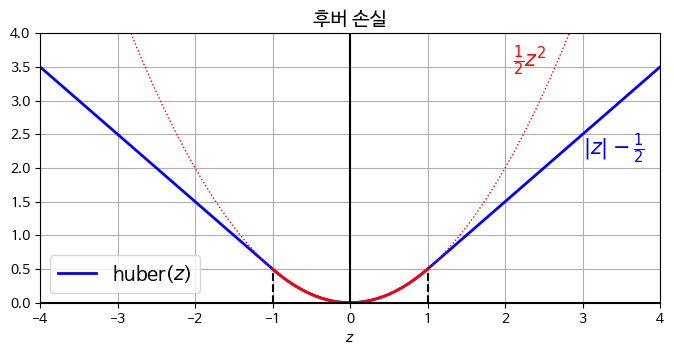

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 3.5))
z = np.linspace(-4, 4, 200)
z_center = np.linspace(-1, 1, 200)
plt.plot(z, huber_fn(0, z), "b-", linewidth=2, label="huber($z$)")
plt.plot(z, z ** 2 / 2, "r:", linewidth=1)
plt.plot(z_center, z_center ** 2 / 2, "r", linewidth=2)
plt.plot([-1, -1], [0, huber_fn(0., -1.)], "k--")
plt.plot([1, 1], [0, huber_fn(0., 1.)], "k--")
plt.gca().axhline(y=0, color='k')
plt.gca().axvline(x=0, color='k')
plt.text(2.1, 3.5, r"$\frac{1}{2}z^2$", color="r", fontsize=15)
plt.text(3.0, 2.2, r"$|z| - \frac{1}{2}$", color="b", fontsize=15)
plt.axis([-4, 4, 0, 4])
plt.grid(True)
plt.xlabel("$z$")
plt.legend(fontsize=14)
plt.title("후버 손실", fontsize=14)
plt.show()

------

## 사용자 정의 요소를 가진 모델을 저장하고 로드하기

### 모델 로드
- 사용자 정의 요소를 가진 모델을 `로드` 할 때 이름과 실제 함수를 매핑한 `딕셔너리`를 전달 해야함
  - 그 이름과 객체를 매핑해야함

- 모델 저장

In [ ]:
model.save("my_model_with_a_custom_loss.keras")

- 저장된 모델 로드  : 이름과 객체 매핑

In [ ]:
model = tf.keras.models.load_model("my_model_with_a_custom_loss.keras",
                                   custom_objects={"huber_fn": huber_fn})

- 모델 훈련 테스트

In [ ]:
model.fit(X_train_scaled, y_train, epochs=2,
          validation_data=(X_valid_scaled, y_valid))

Epoch 1/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.2188 - mae: 0.5096 - val_loss: 0.2129 - val_mae: 0.4876
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1990 - mae: 0.4809 - val_loss: 0.1891 - val_mae: 0.4610


### 매개변수를 받는 후버손실함수 생성

In [ ]:
def create_huber(threshold=1.0):
    def huber_fn(y_true, y_pred):
        error = y_true - y_pred
        is_small_error = tf.abs(error) < threshold
        squared_loss = tf.square(error) / 2
        linear_loss  = threshold * tf.abs(error) - threshold ** 2 / 2
        return tf.where(is_small_error, squared_loss, linear_loss)
    return huber_fn

- 로드시 매핑해야 하기 때문에 `create_huber`로 매핑

In [ ]:
model.compile(loss=create_huber(2.0), optimizer="nadam", metrics=["mae"])
model.fit(X_train_scaled, y_train, epochs=2,
          validation_data=(X_valid_scaled, y_valid))

Epoch 1/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.2148 - mae: 0.4689 - val_loss: 0.2084 - val_mae: 0.4504
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.2054 - mae: 0.4597 - val_loss: 0.1807 - val_mae: 0.4340


In [ ]:
model.save("my_model_with_a_custom_loss_threshold_2.keras")

In [ ]:

model = tf.keras.models.load_model("my_model_with_a_custom_loss_threshold_2.keras",
                                   custom_objects={"huber_fn": create_huber(2.0)})ㅠ

In [ ]:
model.fit(X_train_scaled, y_train, epochs=2,
          validation_data=(X_valid_scaled, y_valid))

Epoch 1/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.2000 - mae: 0.4540 - val_loss: 0.1853 - val_mae: 0.4339
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1959 - mae: 0.4490 - val_loss: 0.1976 - val_mae: 0.4367


### threshold 값을 지정하지 않는 함수

In [ ]:
class HuberLoss(tf.keras.losses.Loss):
    def __init__(self, threshold=1.0, **kwargs):
        self.threshold = threshold
        super().__init__(**kwargs)

    def call(self, y_true, y_pred):
        error = y_true - y_pred
        is_small_error = tf.abs(error) < self.threshold
        squared_loss = tf.square(error) / 2
        linear_loss  = self.threshold * tf.abs(error) - self.threshold**2 / 2
        return tf.where(is_small_error, squared_loss, linear_loss)

    def get_config(self):
        base_config = super().get_config()
        return {**base_config, "threshold": self.threshold}

In [ ]:
tf.keras.utils.set_random_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(30, activation="relu", kernel_initializer="he_normal",
                          input_shape=input_shape),
    tf.keras.layers.Dense(1),
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(loss=HuberLoss(2.), optimizer="nadam", metrics=["mae"])

In [ ]:
model.fit(X_train_scaled, y_train, epochs=2,
          validation_data=(X_valid_scaled, y_valid))

Epoch 1/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.0512 - mae: 1.1438 - val_loss: 0.5086 - val_mae: 0.6718
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3170 - mae: 0.5816 - val_loss: 0.3527 - val_mae: 0.5571


In [ ]:
model.save("my_model_with_a_custom_loss_class.keras")

In [ ]:
model = tf.keras.models.load_model("my_model_with_a_custom_loss_class.keras",
                                   custom_objects={"HuberLoss": HuberLoss})

In [ ]:
model.fit(X_train_scaled, y_train, epochs=2,
          validation_data=(X_valid_scaled, y_valid))

Epoch 1/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.2612 - mae: 0.5244 - val_loss: 0.2689 - val_mae: 0.4982
Epoch 2/2
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2328 - mae: 0.4929 - val_loss: 0.2207 - val_mae: 0.4657


In [ ]:
model.loss.threshold

2.0